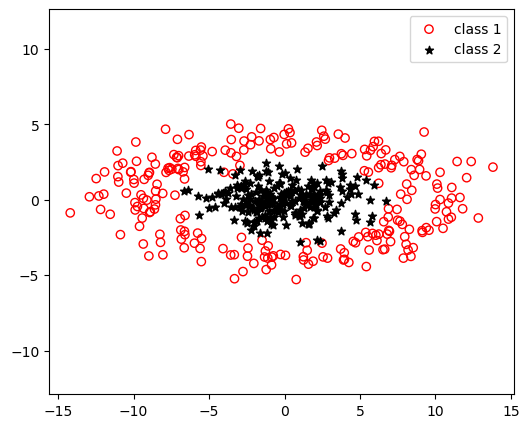

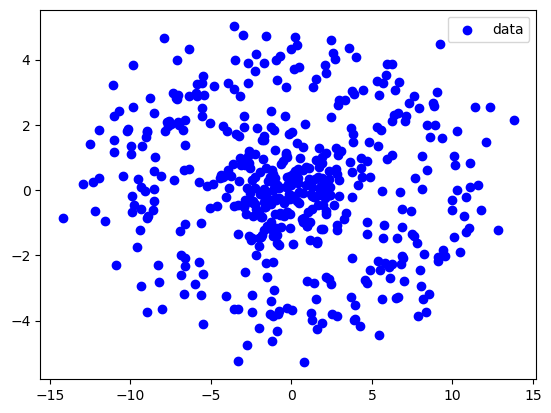

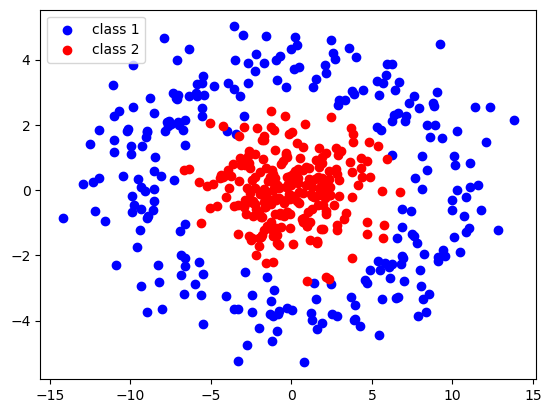

In [1]:
import som
import numpy as np
import matplotlib.pyplot as plt

In [6]:
data=som.data
outer=som.outer
inner=som.inner
weights=som.som_loop(data)

RBFNN Accuracy: 0.9540


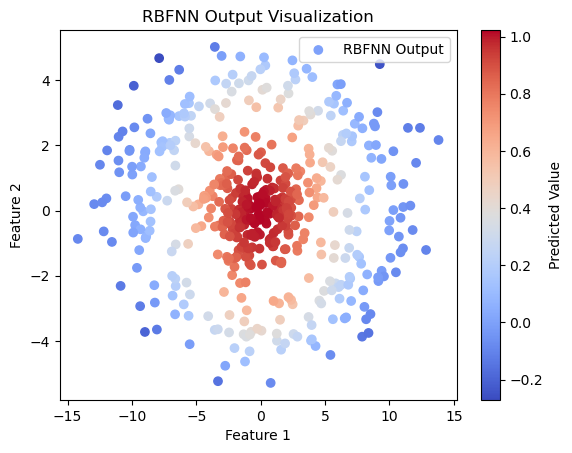

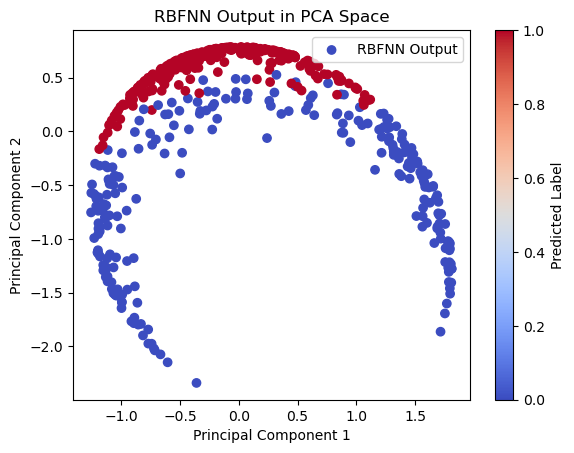

In [15]:
def nonlinear_map(x,centers,sigma):
    o=[]
    for c in centers:
        phi=np.exp(-np.linalg.norm(x-c)**2/(2*sigma**2))
        o.append(phi)
    return np.array(o)

def ols(O,y,lambda_):
    w=np.linalg.inv(O.T@O+lambda_*np.eye(O.shape[1]))@O.T@y
    y_pred=O@w
    return w, y_pred

def aggregate(X,centers,sigma):
    O=[]
    for x in X:
        o=nonlinear_map(x,centers,sigma)
        O.append(o)
    return np.array(O)

def visualize(X,y_pred):
    plt.scatter(X[:,0],X[:,1],c=y_pred, cmap='coolwarm', label='RBFNN Output')
    plt.colorbar(label='Predicted Value')
    plt.title("RBFNN Output Visualization")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

def main():
    centers=weights.reshape(-1,2)
    sigma=np.mean(np.linalg.norm(centers[:,None,:]-centers[None,:,:],axis=2))
    O=aggregate(data,centers,sigma)
    y=np.array([0]*len(outer)+[1]*len(inner))
    w, y_pred=ols(O,y,lambda_=0.1)
    #accuracy
    y_pred_label=(y_pred>0.5).astype(int)
    accuracy=np.mean(y_pred_label==y)
    print(f"RBFNN Accuracy: {accuracy:.4f}")
    visualize(data, y_pred)
    #use pca to visualize the output and decision boundary
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    O_pca = pca.fit_transform(O)
    plt.scatter(O_pca[:,0], O_pca[:,1], c=y_pred_label, cmap='coolwarm', label='RBFNN Output')
    plt.colorbar(label='Predicted Label')
    plt.title("RBFNN Output in PCA Space")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.show()

    

if __name__ == "__main__":
    main()